# Лабораторная работа № 4. Поиск объекта методами спектральной корреляции

Карта: (1400, 1246), кадр: (320, 320)


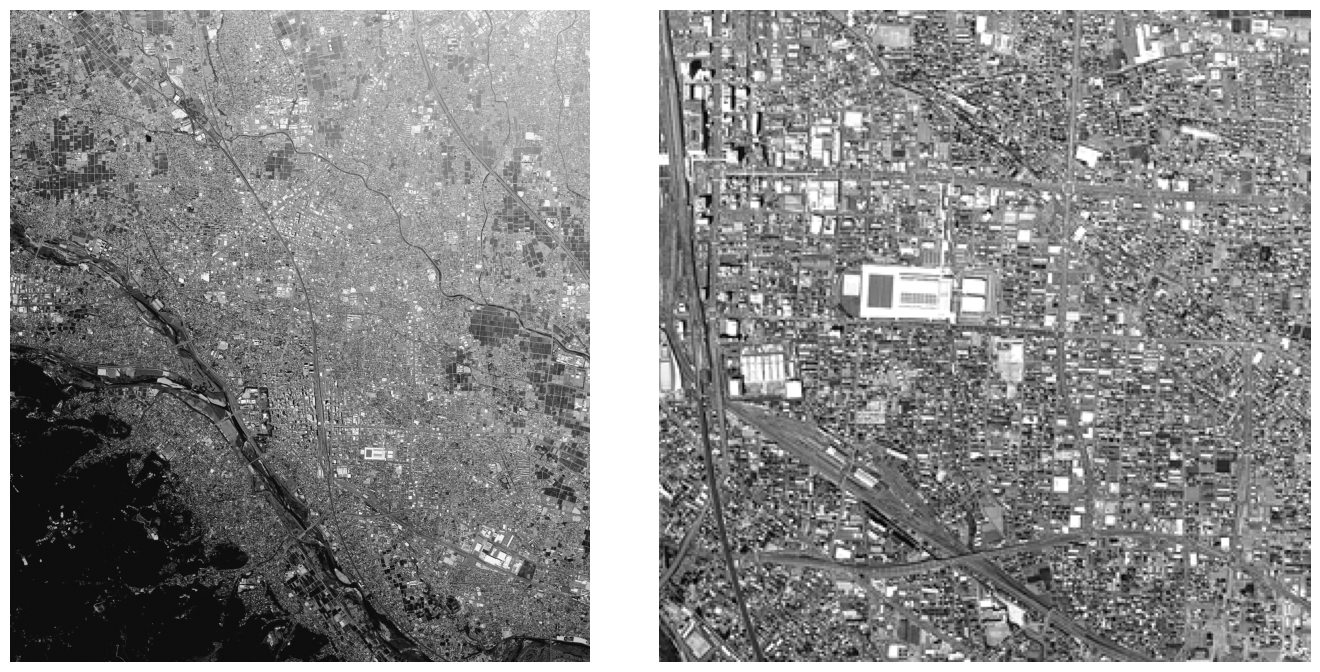

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.filters import sobel, threshold_otsu
from skimage.transform import rotate, resize
from scipy.ndimage import convolve

from time import perf_counter
from pathlib import Path

plt.rcParams['font.family'] = ["Times New Roman"]
plt.rcParams['font.size'] = 16 

ROOT_DIR = Path.cwd().parent
MAP_PATH = ROOT_DIR / "data/lr4/concord_map.png"
FRAME_PATH = ROOT_DIR / "data/lr4/west_frame.png"

A = imread(MAP_PATH).astype(np.float64)    # карта
B = imread(FRAME_PATH).astype(np.float64)  # кадр (фрагмент карты, осветлённый на +20)

h, w = A.shape
h1, w1 = B.shape
print(f"Карта: {A.shape}, кадр: {B.shape}")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(A, cmap='gray')
ax[1].imshow(B, cmap='gray')
for a in ax:
    a.axis('off')
    
plt.tight_layout()
plt.show()

## Часть 1. Прямой метод расчета корреляционной функции

Прямая формула: `R(x,y) = ΣΣ A(x+dx, y+dy)·B(dx, dy)`. Сложность: `(h−h1)·(w−w1)·h1·w1` операций.

In [2]:
# Прямой метод на маленьком фрагменте, чтобы оценить трудоемкость полного расчета
A_small = A[:150, :150]
B_small = B[:50, :50]
hs, ws = A_small.shape
h1s, w1s = B_small.shape

t0 = perf_counter()
R_small = np.zeros((hs - h1s, ws - w1s))
for x in range(ws - w1s):
    if x % 10 == 0:
        print(f'строка x = {x}')   # диагностический вывод номера строки
    for y in range(hs - h1s):
        R_small[y, x] = np.sum(A_small[y:y + h1s, x:x + w1s] * B_small)
t_small = perf_counter() - t0

ops_small = (hs - h1s) * (ws - w1s) * h1s * w1s
ops_full = (h - h1) * (w - w1) * h1 * w1
t_full_est = t_small * ops_full / ops_small

print(f'\nМаленький расчет: {ops_small:.2e} операций за {t_small:.3f} c')
print(f'Полный расчет:    {ops_full:.2e} операций')
print(f'Оценка времени полного расчета: {t_full_est / 3600:.1f} часов')

строка x = 0
строка x = 10
строка x = 20
строка x = 30
строка x = 40
строка x = 50
строка x = 60
строка x = 70
строка x = 80
строка x = 90

Маленький расчет: 2.50e+07 операций за 0.123 c
Полный расчет:    1.02e+11 операций
Оценка времени полного расчета: 0.1 часов


**Вывод по части 1.** Прямой расчет корреляционной функции на полном изображении
занял бы часы и более (оценка приведена в ячейке выше) — сотни миллиардов
попарных произведений.

## Часть 2. Спектральный расчет корреляции

По теореме о спектре свертки кольцевую свертку (а значит, и корреляцию) можно
посчитать через почленное произведение спектров: `R(A,B) = F⁻¹[F(A)·F*(B)]`,
где кадр `B` дополняется нулями до размера карты. Объем вычислений падает на
несколько порядков.

Время спектрального расчета: 0.4773 c
(прямой метод оценивался в часы — ускорение на 4-5 порядков)


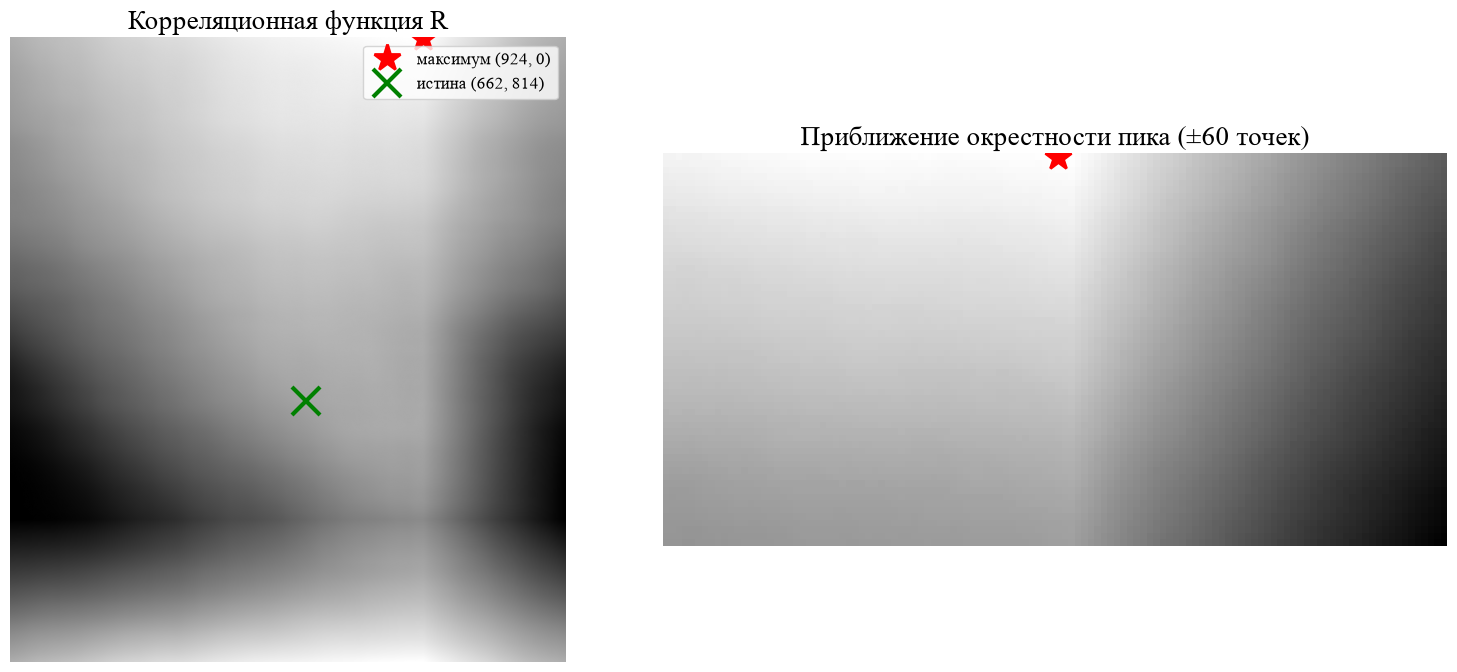

In [2]:
def find_corr(A, B):
    """Спектральная корреляция: R = F^-1[F(A) * conj(F(B))]"""
    h, w = A.shape
    Sa = np.fft.fft2(A)
    Sb = np.fft.fft2(B, s=(h, w))
    return np.real(np.fft.ifft2(Sa * np.conj(Sb)))


def peak_xy(R):
    """Координаты (x, y) максимума корреляционной функции."""
    y, x = np.unravel_index(np.argmax(R), R.shape)
    return x, y


def show_corr(R, title, truth=None, zoom=60):
    """Корреляционная функция: общий вид + приближение окрестности максимума.

    Пик отмечен красной звездочкой; truth — истинное положение (зелёный крестик).
    """
    x, y = peak_xy(R)
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    ax[0].imshow(R, cmap='gray')
    ax[0].plot(x, y, 'r*', markersize=20, mew=2, label=f'максимум ({x}, {y})')
    if truth is not None:
        ax[0].plot(truth[0], truth[1], 'gx', markersize=20, mew=3,
                   label=f'истина {truth}')
    ax[0].set_title(title)
    ax[0].legend(loc='upper right', fontsize=12)
    ax[0].axis('off')
    x0, x1 = max(0, x - zoom), min(R.shape[1], x + zoom)
    y0, y1 = max(0, y - zoom), min(R.shape[0], y + zoom)
    ax[1].imshow(R[y0:y1, x0:x1], cmap='gray', interpolation='nearest')
    ax[1].plot(x - x0, y - y0, 'r*', markersize=20, mew=2)
    if truth is not None and x0 <= truth[0] < x1 and y0 <= truth[1] < y1:
        ax[1].plot(truth[0] - x0, truth[1] - y0, 'gx', markersize=20, mew=3)
    ax[1].set_title(f'Приближение окрестности пика (±{zoom} точек)')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
    return fig


t0 = perf_counter()
R = find_corr(A, B)
t_sp = perf_counter() - t0
print(f'Время спектрального расчета: {t_sp:.4f} c')
print('(прямой метод оценивался в часы — ускорение на 4-5 порядков)')

fig = show_corr(R, 'Корреляционная функция R', truth=(662, 814))
fig.savefig(ROOT_DIR / "data/lr4/corr_spektr.png")

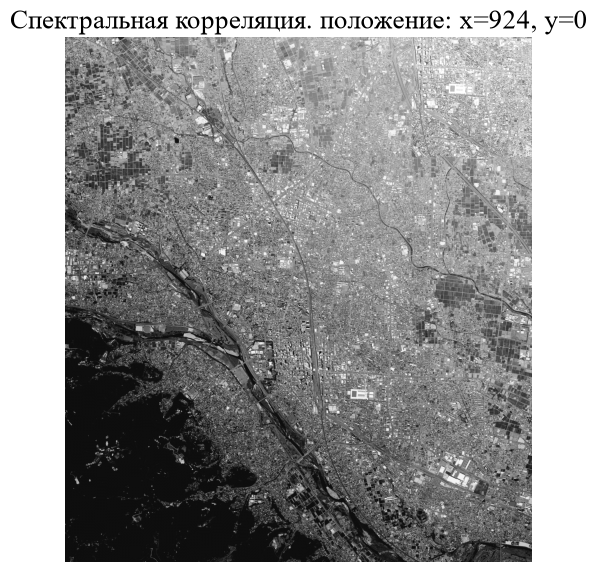

Максимум R: x=924, y=0; истинное положение: x=662, y=814


In [4]:
def show_found(A, B, R, title='', save_flag = False, fig_name = ''):
    x, y = peak_xy(R)
    x = min(max(x, 0), w - w1)
    y = min(max(y, 0), h - h1)
    A2 = A.copy()
    A2[y:y + h1, x:x + w1] = np.clip(B + 50, 0, 255)
    fig = plt.figure(figsize=(8, 6))
    plt.imshow(A2, cmap='gray')
    plt.title(f'{title}положение: x={x}, y={y}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    if save_flag:
    	fig.savefig(ROOT_DIR / "data/lr4" / fig_name)
    
    return x, y


x, y = show_found(A, B, R, 'Спектральная корреляция. ')
print(f'Максимум R: x={x}, y={y}; истинное положение: x=662, y=814')

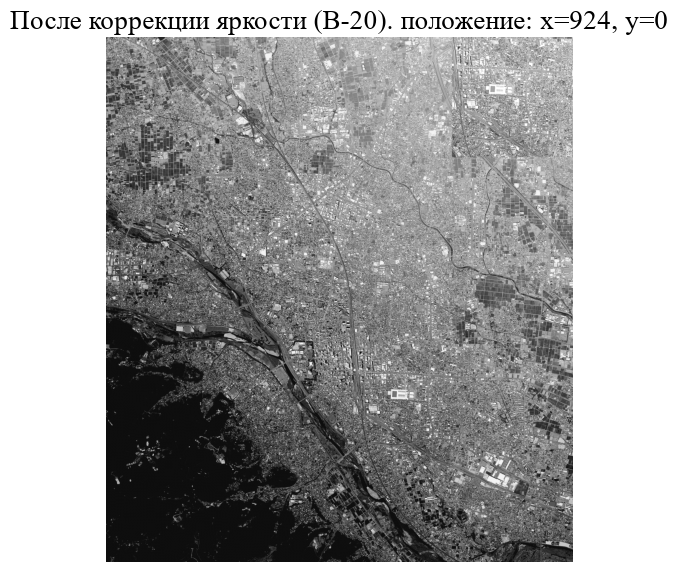

Максимум R: x=924, y=0
R в истинном положении: 1.758e+09, R в максимуме: 2.302e+09


In [5]:
# Коррекция яркости кадра: условия освещенности карты и кадра различаются
B_corr = np.clip(B - 20, 0, 255)
R2 = find_corr(A, B_corr)
x2, y2 = show_found(A, B_corr, R2, 'После коррекции яркости (B-20). ')
print(f'Максимум R: x={x2}, y={y2}')
print(f'R в истинном положении: {R2[814, 662]:.3e}, R в максимуме: {R2.max():.3e}')

**Вывод по части 2.** Спектральный расчет занимает доли секунды вместо часов —
теперь метод применим и в приложениях реальном времени. Однако корреляция по
яркости чувствительна к освещённости: из-за того, что кадр светлее карты, в
корреляционной функции появляется ложный обширный максимум в ярком районе
карты (поля в правом верхнем углу), и наивный поиск даёт неверное положение.
В оригинальной лабораторной ручная коррекция `B − 20` устраняет ложный максимум;
на нашем снимке яркий район настолько контрастен, что даже после коррекции его
отклик остаётся выше отклика в истинном положении (численное сравнение приведено
в ячейке выше). Вывод тот же, но более сильный: корреляция по яркости ненадёжна,
и в реальной задаче величину сдвига яркости заранее не знают — поэтому нужны
устойчивые методы (части 3–5).

## Часть 3. Фазовая корреляция

По теореме о спектре сдвига при чистом сдвиге амплитуда спектра не меняется —
вся информация о положении находится в фазе. Отбросим амплитуду кросс-спектра,
разделив каждый элемент на свой модуль:
`R(A,B) = F⁻¹[F(A)·F*(B) / |F(A)·F*(B)|]`.

Время фазовой корреляции: 0.6098 c


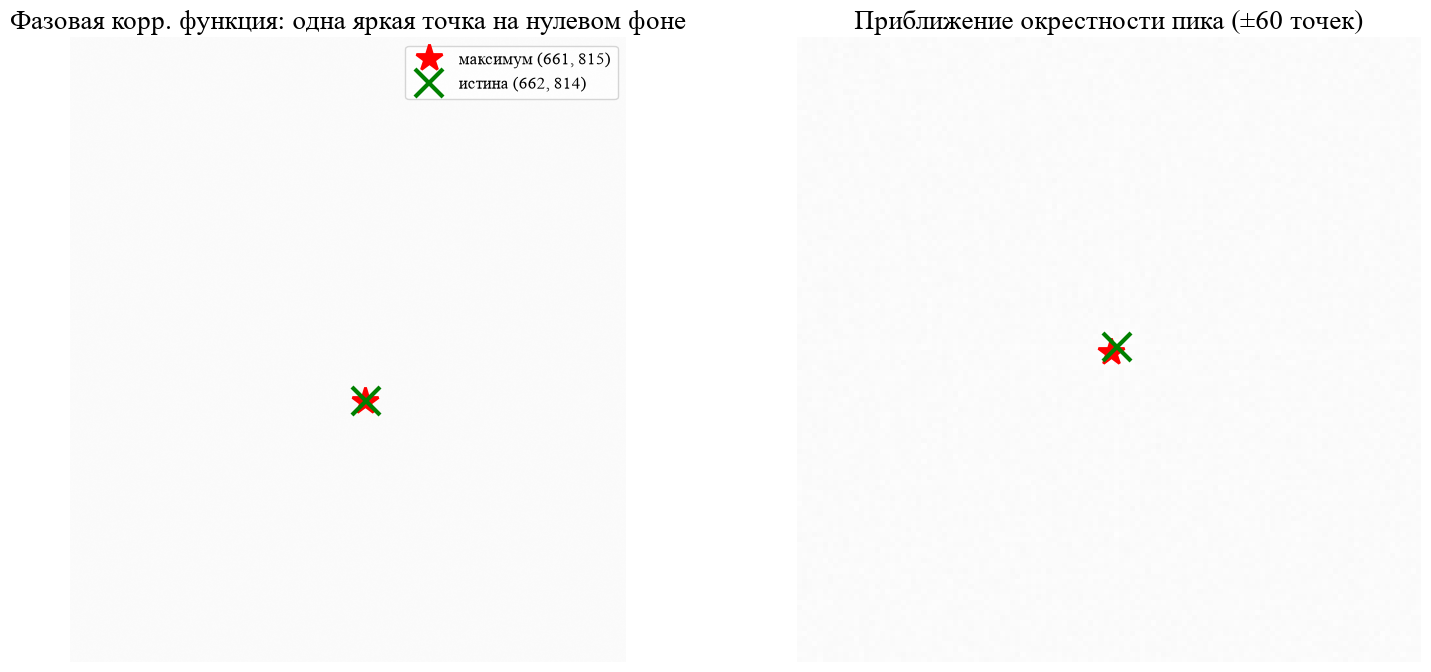

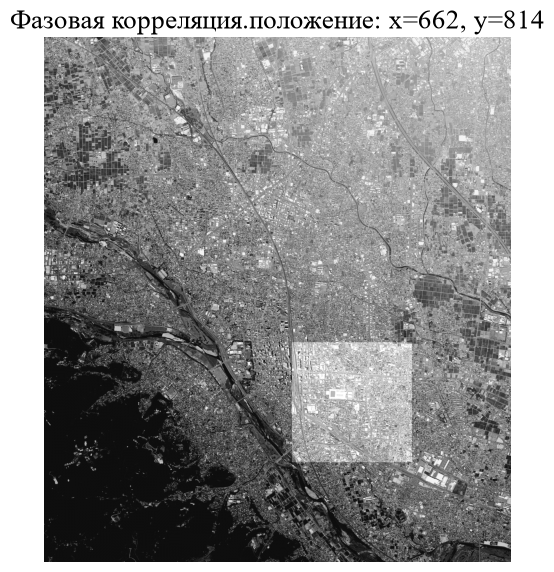

Максимум R: x=662, y=814; истинное положение: x=662, y=814


In [6]:
def phase_corr(A, B):
    """Фазовая корреляция: амплитуда кросс-спектра отбрасывается."""
    h, w = A.shape
    Sa = np.fft.fft2(A)
    Sb = np.fft.fft2(B, s=(h, w))
    Sr = Sa * np.conj(Sb)
    Sr = Sr / (np.abs(Sr) + 1e-12)   # оставляем только фазу спектра
    return np.real(np.fft.ifft2(Sr))


t0 = perf_counter()
Rp = phase_corr(A, B)
t_ph = perf_counter() - t0
print(f'Время фазовой корреляции: {t_ph:.4f} c')

fig = show_corr(-Rp, 'Фазовая корр. функция: одна яркая точка на нулевом фоне',
                truth=(662, 814))
fig.savefig(ROOT_DIR / "data/lr4/corr_phase.png")

x, y = show_found(A, B, Rp, 'Фазовая корреляция.', True, "corr_phase_result")
print(f'Максимум R: x={x}, y={y}; истинное положение: x=662, y=814')

---//--- Фазовая корреляция: влияние яркости кадра ---//---
  B-100: пик (662, 814)
  B-50: пик (662, 814)
  B-20: пик (662, 814)
  B+20: пик (662, 814)
  B+50: пик (662, 814)
  B+100: пик (662, 814)
---//--- Фазовая корреляция: шум salt & pepper 25% ---//---


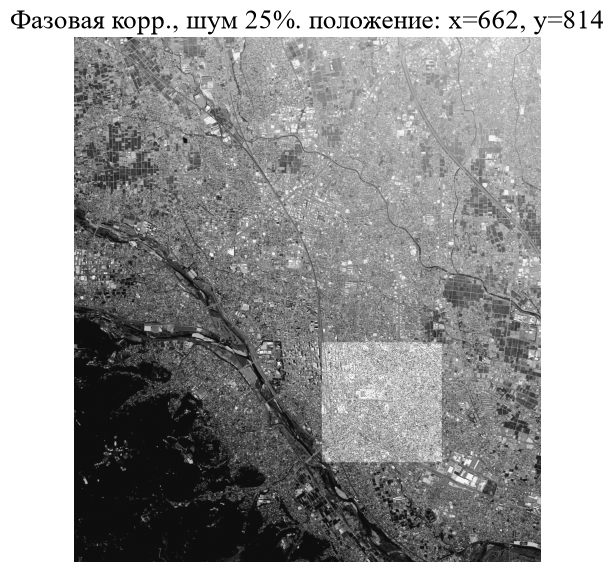

  пик (662, 814)
---//--- Фазовая корреляция: поворот кадра на 3 градуса ---//---
  пик (378, 536)
---//--- Фазовая корреляция: масштаб 0.92 ---//---
  пик (528, 607)


In [7]:
def salt_pepper(img, amount, seed=42):
    """Шум "соль и перец" (аналог imnoise(B,'salt & pepper',amount))."""
    rng = np.random.default_rng(seed)
    out = img.copy().ravel()
    n = int(amount * img.size)
    idx = rng.choice(img.size, size=n, replace=False)
    out[idx[:n // 2]] = 0
    out[idx[n // 2:]] = 255
    return out.reshape(img.shape)


print('---//--- Фазовая корреляция: влияние яркости кадра ---//---')
for d in [-100, -50, -20, 20, 50, 100]:
    x, y = peak_xy(phase_corr(A, np.clip(B + d, 0, 255)))
    print(f'  B{d:+d}: пик ({x}, {y})')

print('---//--- Фазовая корреляция: шум salt & pepper 25% ---//---')
Bn = salt_pepper(B, 0.25)
x, y = show_found(A, Bn, phase_corr(A, Bn), 'Фазовая корр., шум 25%. ', True, 'corr_phase_noiseAdd')
print(f'  пик ({x}, {y})')

print('---//--- Фазовая корреляция: поворот кадра на 3 градуса ---//---')
Br = rotate(B, 3, resize=False)   # как imrotate: размер сохраняется, фон 0
x, y = peak_xy(phase_corr(A, Br))
print(f'  пик ({x}, {y})')

print('---//--- Фазовая корреляция: масштаб 0.92 ---//---')
Bs = resize(B, (int(h1 * 0.92), int(w1 * 0.92)), anti_aliasing=True)
x, y = peak_xy(phase_corr(A, Bs))
print(f'  пик ({x}, {y})')

**Вывод по части 3.** Фазовая корреляция находит кадр точно и совершенно
нечувствительна к изменению освещённости (±20, ±50, ±100 — положение не меняется)
и к шуму: корреляционная функция остаётся острой дельта-функцией, т.к. шум
«уходит» вместе с амплитудой спектра. Но теорема о спектре сдвига справедлива
только для чистого сдвига: при повороте и масштабировании максимум размывается,
дробится и тонет в шуме — положение кадра найти не удаётся.

## Часть 4. Градиентная корреляция

Коррелируем не яркости, а модули градиентов яркости: дифференцирование удаляет
влияние освещённости. Вариант 1 — по модулю градиента `G = √(Gx² + Gy²)`;
вариант 2 — покомпонентно, `Sr = F(Gax)·F*(Gbx) + F(Gay)·F*(Gby)`.

Градиентная (модуль):  0.6041 c
Градиентная XY:        0.9422 c (медленнее: 4 БПФ вместо 2)


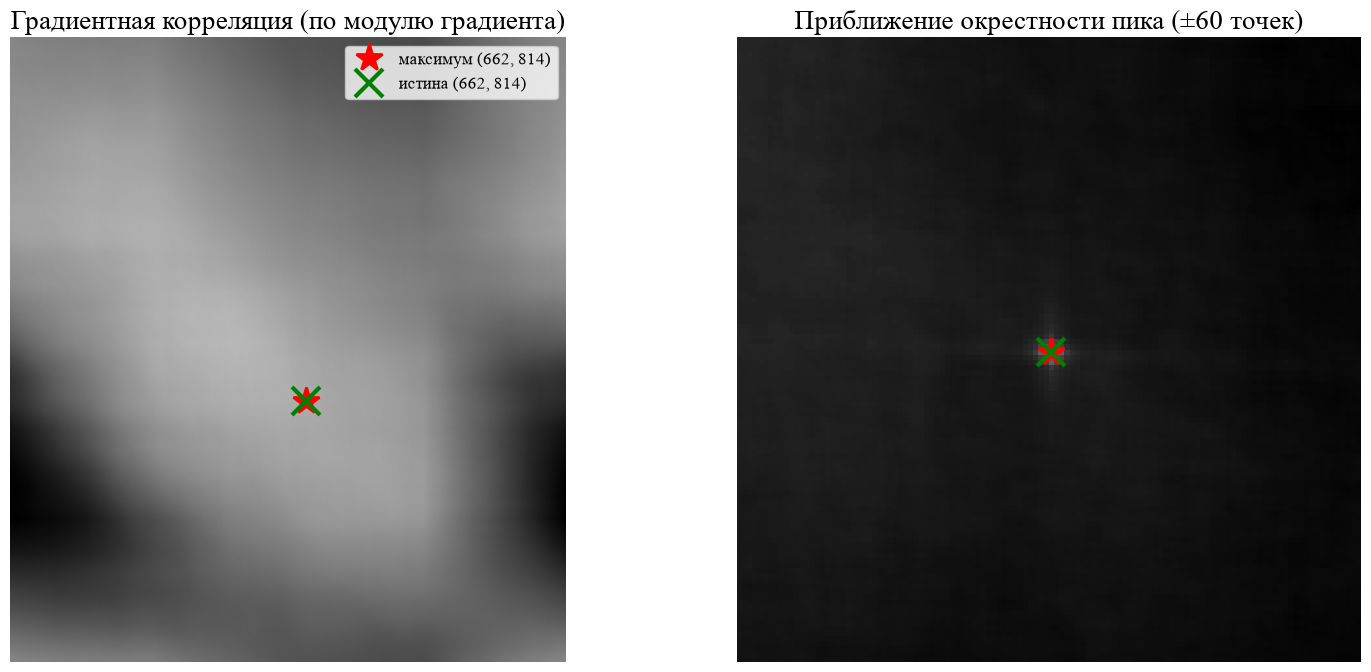

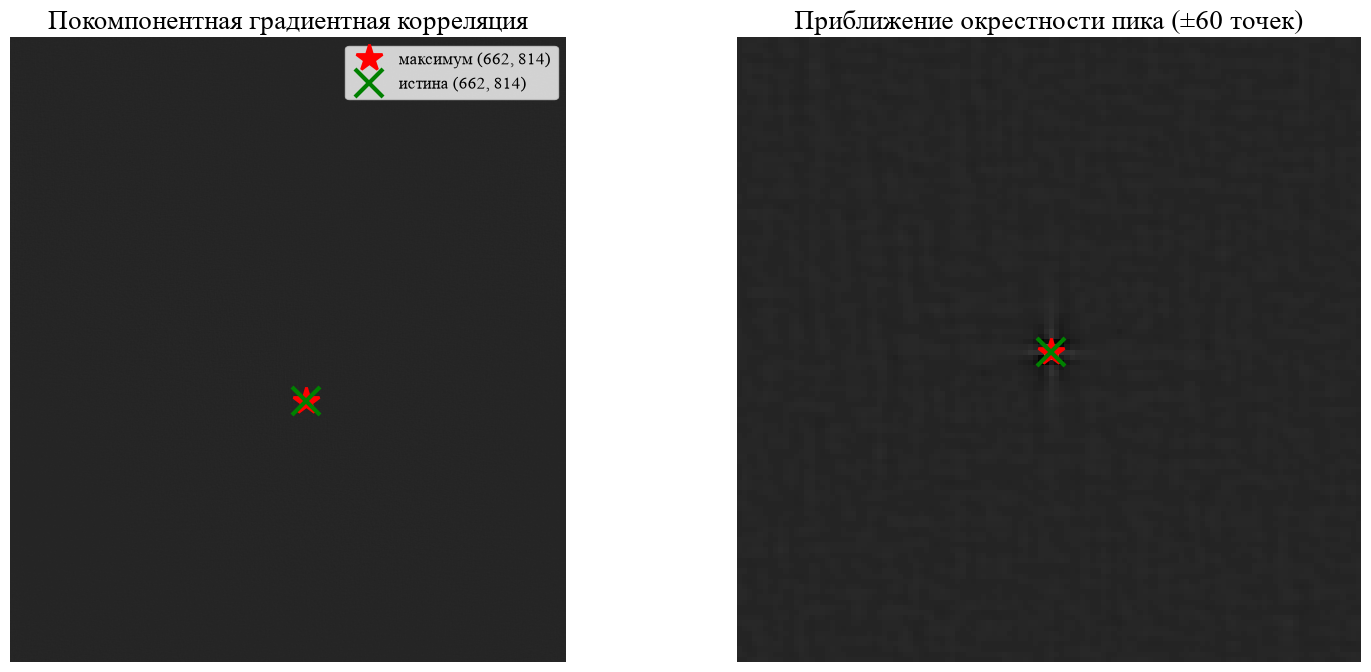

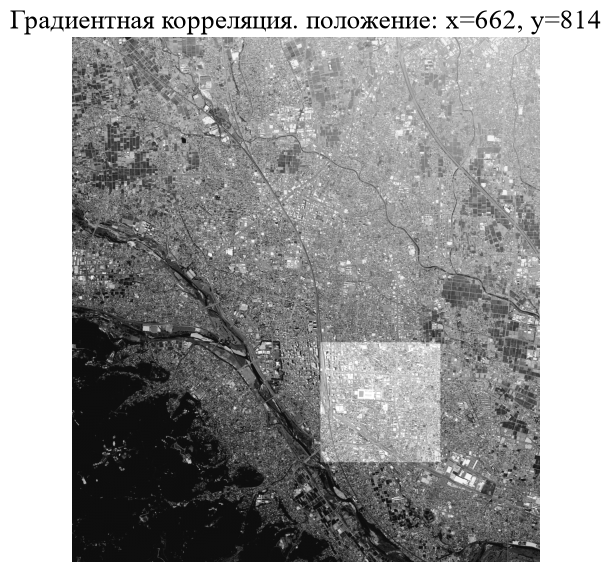

Модуль:  пик (662, 814)


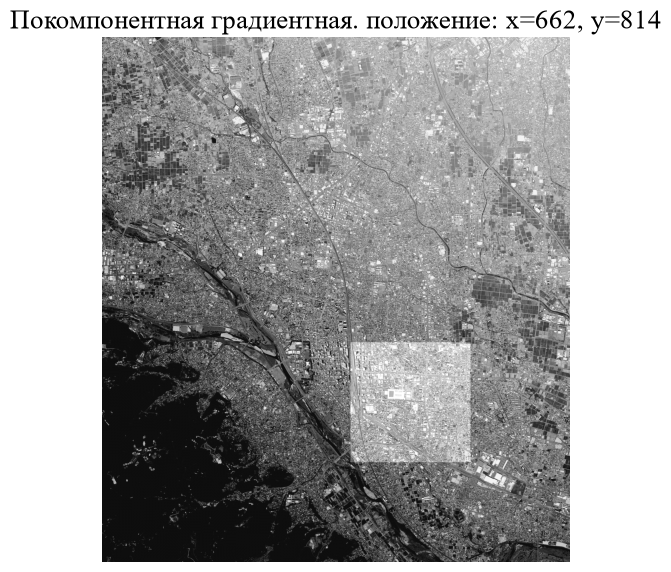

XY:      пик (662, 814)


In [ ]:
Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
Sy = Sx.T


def grad_maps(img):
    """Компоненты и модуль градиента (фильтр Собела)."""
    Gx = convolve(img, Sx)
    Gy = convolve(img, Sy)
    return Gx, Gy, np.hypot(Gx, Gy)


def grad_corr(A, B):
    """Градиентная корреляция по модулю градиента."""
    _, _, Ga = grad_maps(A)
    _, _, Gb = grad_maps(B)
    return find_corr(Ga, Gb)


def grad_corr_xy(A, B):
    """Покомпонентная градиентная корреляция (по Gx и Gy)."""
    Gax, Gay, _ = grad_maps(A)
    Gbx, Gby, _ = grad_maps(B)
    h, w = A.shape
    Sr = (np.fft.fft2(Gax) * np.conj(np.fft.fft2(Gbx, s=(h, w)))
          + np.fft.fft2(Gay) * np.conj(np.fft.fft2(Gby, s=(h, w))))
    return np.real(np.fft.ifft2(Sr))


t0 = perf_counter() 
Rg = grad_corr(A, B) 
tg = perf_counter() - t0

t0 = perf_counter() 
Rgxy = grad_corr_xy(A, B) 
tgxy = perf_counter() - t0

print(f'Градиентная (модуль):  {tg:.4f} c')
print(f'Градиентная XY:        {tgxy:.4f} c (медленнее: 4 БПФ вместо 2)')

fig = show_corr(Rg, 'Градиентная корреляция (по модулю градиента)', truth=(662, 814))
fig.savefig(ROOT_DIR / "data/lr4/corr_grad.png")
fig = show_corr(Rgxy, 'Покомпонентная градиентная корреляция', truth=(662, 814))
fig.savefig(ROOT_DIR / "data/lr4/corr_gradxy.png")

x, y = show_found(A, B, Rg, 'Градиентная корреляция. ')
print(f'Модуль:  пик ({x}, {y})')
x, y = show_found(A, B, Rgxy, 'Покомпонентная градиентная. ')
print(f'XY:      пик ({x}, {y})')

In [ ]:
print('---//--- Градиентная корреляция: влияние факторов ---//---')
for name, fn in [('модуль', grad_corr), ('XY', grad_corr_xy)]:
    print(f'  [{name}] яркость:')
    for d in [-100, -50, 50, 100]:
        x, y = peak_xy(fn(A, np.clip(B + d, 0, 255)))
        print(f'    B{d:+d}: пик ({x}, {y})')
    x, y = peak_xy(fn(A, salt_pepper(B, 0.25)))
    print(f'  [{name}] шум 25%: пик ({x}, {y})')
    x, y = peak_xy(fn(A, rotate(B, 3, resize=False)))
    print(f'  [{name}] поворот 3°: пик ({x}, {y})')
    x, y = peak_xy(fn(A, resize(B, (int(h1 * 0.92), int(w1 * 0.92)), anti_aliasing=True)))
    print(f'  [{name}] масштаб 0.92: пик ({x}, {y})')

--- Градиентная корреляция: влияние факторов ---
  [модуль] яркость:


    B-100: пик (662, 814)


    B-50: пик (662, 814)


    B+50: пик (662, 814)


    B+100: пик (662, 814)


...

    B+50: пик (662, 814)


    B+100: пик (662, 814)


  [XY] шум 25%: пик (662, 814)


  [XY] поворот 3°: пик (668, 809)


  [XY] масштаб 0.92: пик (639, 829)


**Вывод по части 4.** Градиентная корреляция находит кадр, устойчива к изменению
освещённости (градиент от освещения не зависит). Максимум отчётливый, но более
размытый, чем у фазовой корреляции. По серии экспериментов (часть 6)
покомпонентный вариант заметно устойчивее фазовой к повороту (5° против 2°),
а вариант по модулю — наиболее устойчив к масштабированию (97% против 95%). К шуму градиентный метод чувствительнее фазового:
дифференцирование подчёркивает высокочастотные компоненты, и каждая шумовая точка
даёт ненулевой градиент. Покомпонентный вариант (XY) использует информацию о
направлении градиента и работает надёжнее, но медленнее (4 БПФ вместо 2).

## Часть 5. Контурная корреляция

Отказываемся от яркостных признаков совсем: коррелируем только точки контура
(фильтр Собеля + порог Оцу, аналог `edge(A,'Sobel')`). Положение точек контура —
геометрический признак, не зависящий от освещённости.

Время контурной корреляции: 0.7148 c


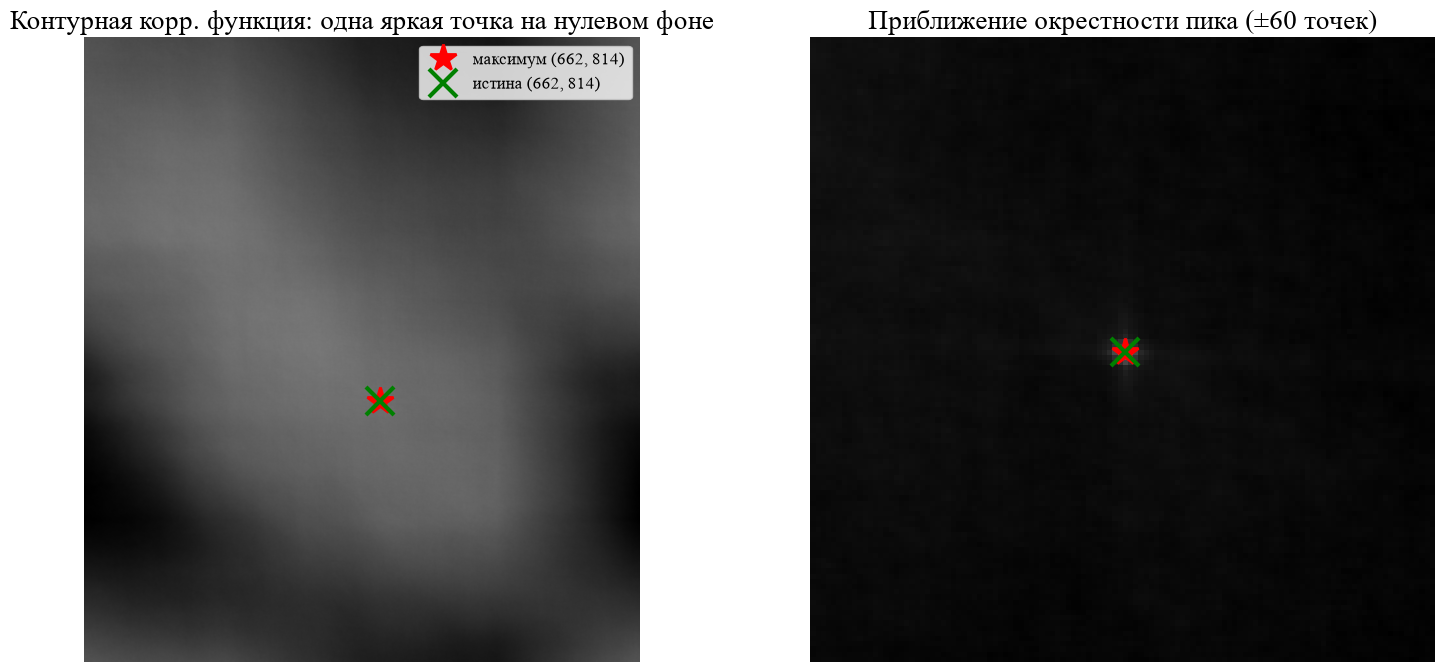

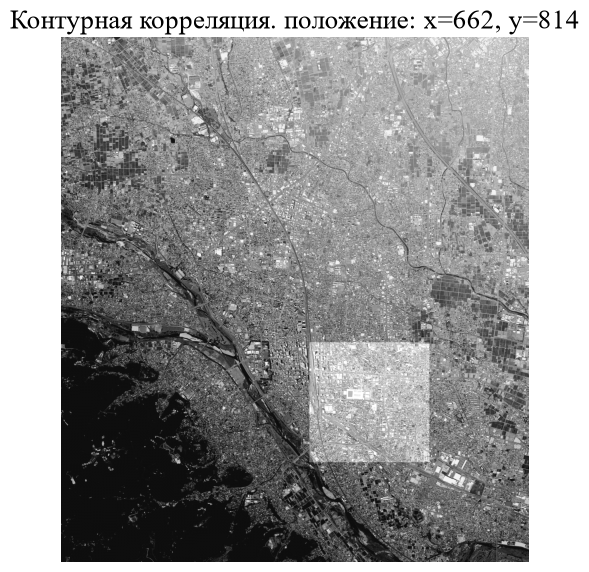

Максимум R: x=662, y=814; истинное положение: x=662, y=814
--- Контурная корреляция: влияние факторов ---
  B-100: пик (662, 814)
  B-50: пик (662, 814)
  B+50: пик (662, 814)
  B+100: пик (662, 814)
  шум 25%: пик (662, 814)
  поворот 3°: пик (537, 706)
  масштаб 0.92: пик (523, 698)


In [11]:
def sobel_edge(img):
    """Точки контура: модуль градиента Собеля с порогом Оцу."""
    g = sobel(img / 255.0)
    return (g > threshold_otsu(g)).astype(np.float64)


def cont_corr(A, B):
    """Контурная корреляция."""
    return find_corr(sobel_edge(A), sobel_edge(B))


t0 = perf_counter()
Rc = cont_corr(A, B)
t_c = perf_counter() - t0
print(f'Время контурной корреляции: {t_c:.4f} c')

fig = show_corr(Rc, 'Контурная корр. функция: одна яркая точка на нулевом фоне',
                truth=(662, 814))
fig.savefig(ROOT_DIR / "data/lr4/corr_cont.png")

x, y = show_found(A, B, Rc, 'Контурная корреляция. ')
print(f'Максимум R: x={x}, y={y}; истинное положение: x=662, y=814')

print('--- Контурная корреляция: влияние факторов ---')
for d in [-100, -50, 50, 100]:
    x, y = peak_xy(cont_corr(A, np.clip(B + d, 0, 255)))
    print(f'  B{d:+d}: пик ({x}, {y})')
x, y = peak_xy(cont_corr(A, salt_pepper(B, 0.25)))
print(f'  шум 25%: пик ({x}, {y})')
x, y = peak_xy(cont_corr(A, rotate(B, 3, resize=False)))
print(f'  поворот 3°: пик ({x}, {y})')
x, y = peak_xy(cont_corr(A, resize(B, (int(h1 * 0.92), int(w1 * 0.92)), anti_aliasing=True)))
print(f'  масштаб 0.92: пик ({x}, {y})')

**Вывод по части 5.** Контурная корреляция даёт один яркий максимум на нулевом
фоне — очень высокая точность поиска (смещение даже на один пиксель резко
уменьшает отклик). Метод нечувствителен к освещённости и менее чувствителен к
геометрическим искажениям, чем фазовая корреляция. Главный недостаток —
чувствительность к шуму: при сильном шуме контуры детектируются неправильно.

## Часть 6. Сравнение методов

Исследуем устойчивость четырёх методов (фазовая, градиентная, покомпонентная
градиентная, контурная) к шуму (0–100%, шаг 10%), повороту (0–20°, шаг 1°) и
масштабированию (100–80%, шаг 1%). Ошибка — отклонение найденного положения от
истинного; критическая — первая, где ошибка превышает 20 точек.

In [12]:
methods = {
    'Фазовая': phase_corr,
    'Градиентная': grad_corr,
    'Градиентная XY': grad_corr_xy,
    'Контурная': cont_corr,
}

# Истинное положение — по фазовой корреляции на чистом кадре
xtrue, ytrue = peak_xy(phase_corr(A, B))
print(f'Истинное положение: ({xtrue}, {ytrue})')

CRIT = 20  # допустимая ошибка, точек


def error_of(fn, B1):
    x, y = peak_xy(fn(A, B1))
    return int(round(np.hypot(x - xtrue, y - ytrue)))


noise_levels = list(range(0, 101, 10))
angles = list(range(0, 21))
scales = list(range(100, 79, -1))

E_noise = {name: [] for name in methods}
E_rot = {name: [] for name in methods}
E_scale = {name: [] for name in methods}

for name, fn in methods.items():
    for n in noise_levels:
        E_noise[name].append(error_of(fn, salt_pepper(B, n / 100)))
    for a in angles:
        E_rot[name].append(error_of(fn, rotate(B, a, resize=False) if a else B))
    for s in scales:
        Bs = resize(B, (int(h1 * s / 100), int(w1 * s / 100)), anti_aliasing=True) if s < 100 else B
        E_scale[name].append(error_of(fn, Bs))
    print(f'{name}: шум {E_noise[name]}')
    print(f'{"":>16} поворот {E_rot[name]}')
    print(f'{"":>16} масштаб {E_scale[name]}')


Истинное положение: (662, 814)
Фазовая: шум [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 322]
                 поворот [0, 2, 498, 397, 19, 797, 503, 208, 261, 112, 196, 334, 132, 549, 349, 332, 680, 297, 255, 39, 121]
                 масштаб [0, 3, 6, 8, 8, 676, 11, 651, 247, 282, 152, 555, 299, 168, 197, 28, 68, 535, 287, 622, 217]
Градиентная: шум [0, 0, 0, 0, 211, 208, 206, 206, 213, 211, 209]
                 поворот [0, 0, 202, 208, 206, 197, 194, 196, 197, 198, 196, 198, 198, 199, 206, 208, 208, 209, 208, 207, 209]
                 масштаб [0, 2, 5, 201, 196, 194, 192, 191, 200, 178, 176, 185, 179, 189, 187, 187, 219, 216, 215, 207, 205]
Градиентная XY: шум [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 522]
                 поворот [0, 1, 4, 8, 8, 287, 303, 634, 274, 375, 94, 10, 343, 651, 225, 404, 244, 390, 869, 512, 362]
                 масштаб [0, 2, 5, 3, 3, 7, 8, 9, 27, 361, 8, 96, 50, 320, 126, 56, 14, 58, 803, 60, 414]
Контурная: шум [0, 0, 0, 0, 0, 0, 207, 200, 190, 203, 199]
                 пов

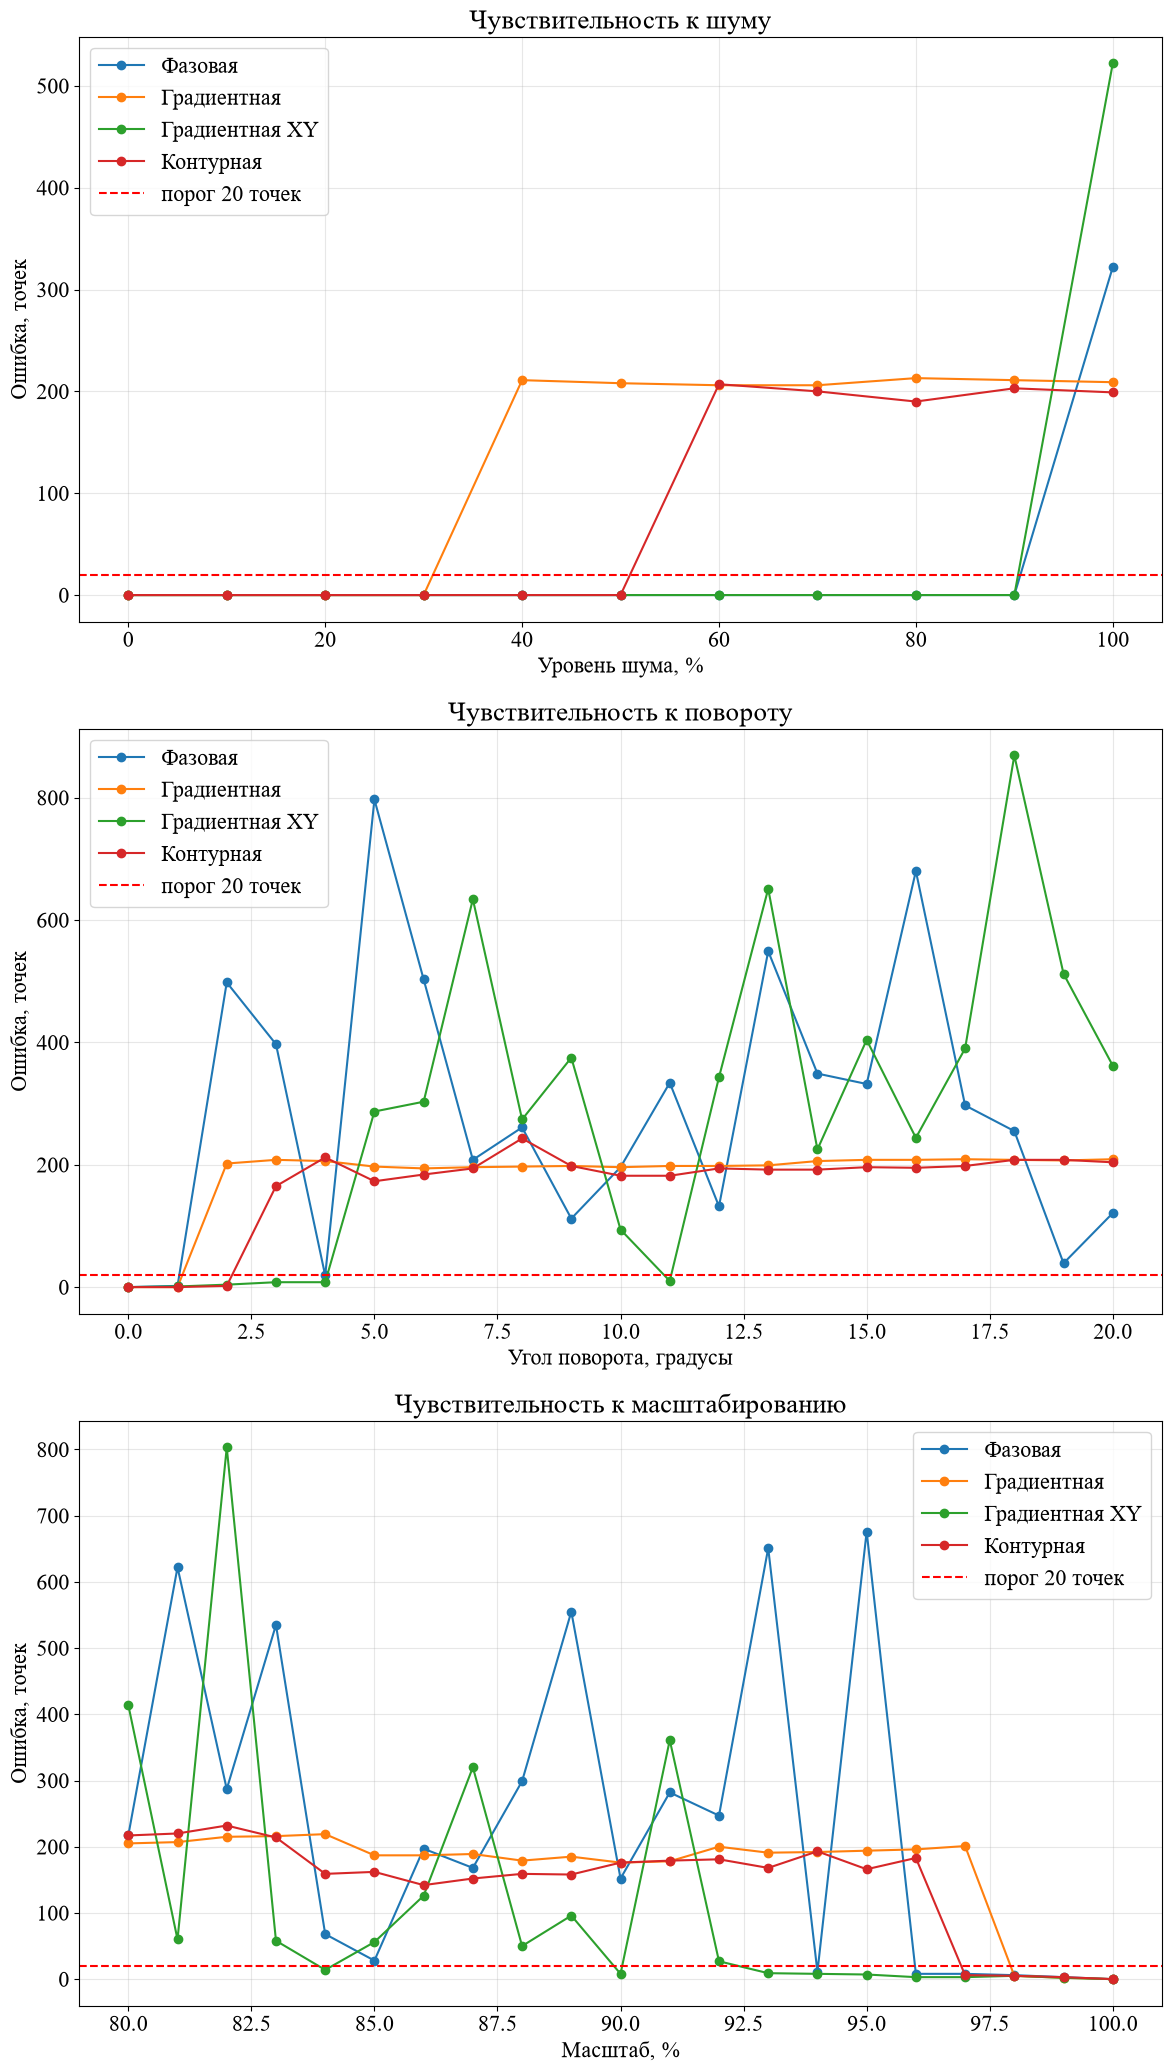

Критические значения (первая ошибка > 20 точек):
Метод              шум, % поворот, °  масштаб, %
Фазовая               100          2          95
Градиентная            40          2          97
Градиентная XY        100          5          92
Контурная              60          3          96


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 21))

for name in methods:
    axes[0].plot(noise_levels, E_noise[name], 'o-', label=name)
    
axes[0].axhline(CRIT, color='r', ls='--', label='порог 20 точек')
axes[0].set_title('Чувствительность к шуму')
axes[0].set_xlabel('Уровень шума, %')
axes[0].set_ylabel('Ошибка, точек')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name in methods:
    axes[1].plot(angles, E_rot[name], 'o-', label=name)
axes[1].axhline(CRIT, color='r', ls='--', label='порог 20 точек')
axes[1].set_title('Чувствительность к повороту')
axes[1].set_xlabel('Угол поворота, градусы')
axes[1].set_ylabel('Ошибка, точек')
axes[1].legend()
axes[1].grid(alpha=0.3)

for name in methods:
    axes[2].plot(scales, E_scale[name], 'o-', label=name)
axes[2].axhline(CRIT, color='r', ls='--', label='порог 20 точек')
axes[2].set_title('Чувствительность к масштабированию')
axes[2].set_xlabel('Масштаб, %')
axes[2].set_ylabel('Ошибка, точек')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


def critical(levels, errors):
    for lv, e in zip(levels, errors):
        if e > CRIT:
            return lv
    return '— (> max)'


print('Критические значения (первая ошибка > 20 точек):')
print(f'{"Метод":<16} {"шум, %":>8} {"поворот, °":>10} {"масштаб, %":>11}')
for name in methods:
    print(f'{name:<16} {critical(noise_levels, E_noise[name]):>8} '
          f'{critical(angles, E_rot[name]):>10} {critical(scales, E_scale[name]):>11}')
    
    
fig.savefig(ROOT_DIR / "data/lr4/compareAllMethods.png")


In [16]:
# Время работы каждого метода (среднее по 3 вызовам на чистой паре)
print('Время работы методов, с (среднее по 3 прогонам):')
for name, fn in methods.items():
    ts = []
    for _ in range(3):
        t0 = perf_counter()
        fn(A, B)
        ts.append(perf_counter() - t0)
    print(f'  {name:<16} {np.mean(ts):.4f}')


Время работы методов, с (среднее по 3 прогонам):
  Фазовая          0.5343
  Градиентная      0.5576
  Градиентная XY   0.7924
  Контурная        0.6131


## Выводы по сравнению методов

Результаты измерений приведены в таблицах выше. Закономерности (критическое
значение — первое, где ошибка превышает 20 точек):

- **К шуму наиболее устойчивы фазовая и покомпонентная градиентная корреляция**
  (критический уровень шума 100%), **наименее — градиентная по модулю** (40%):
  дифференцирование усиливает высокочастотный шум. Контурная — средняя (60%):
  при сильном шуме контуры детектируются неправильно.
- **К повороту наиболее устойчива покомпонентная градиентная** (критический угол
  5°), **наименее — фазовая и градиентная по модулю** (2°): теорема о спектре
  сдвига работает только для чистого сдвига, и фазовый максимум размывается
  первым. Контурная — 3°.
- **К масштабированию наиболее устойчива градиентная по модулю** (97%) — модуль
  градиента при пересчёте размера меняется плавно, **наименее — покомпонентная
  градиентная** (92%): покомпонентная схема жёстче привязана к точному совпадению
  направлений градиентов, которые при интерполяции рассогласовываются. Контурная
  (96%) и фазовая (95%) — в середине.
- **Наиболее точные — фазовая и контурная корреляция** (дельта-пик на нулевом
  фоне); **наименее точная — градиентная по модулю** (размытый максимум).
- **Скорость** всех спектральных методов — доли секунды (≈0.4–0.8 с по среднему
  из 3 прогонов); медленнее всех покомпонентная градиентная (4 БПФ вместо 2).

Итог: универсального метода нет. При чистом сдвиге и неизвестной освещённости
лучшая точность у фазовой корреляции; при возможных геометрических искажениях
надёжнее покомпонентная градиентная корреляция.